# Dataset Dataview

Load one or more motor dataset CSV files and inspect the distribution of `qvel` and `qact`.

Set `DATASET_PATHS` to CSV files, directories, or glob patterns. The notebook validates that each loaded file contains `time_s`, `qpos`, `qvel`, and `qact`, then shows summary statistics, a scatter plot, and a binned occupancy heatmap for the `(qvel, qact)` field.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/home/slava/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Configuration

Edit `DATASET_PATHS` to point at the datasets you want to inspect. Each entry may be:

- a CSV file
- a directory containing CSV files
- a glob pattern such as `data/raw/chirp_*.csv`

Paths are resolved relative to the project root unless absolute.

In [ ]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()

DATASET_PATHS = [
    # PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "raw" / "chirp_0p1_2hz_amp8.csv",
    # PROJECT_ROOT / "data" / "raw" / "steps_*.csv",
]

REQUIRED_COLUMNS = ["time_s", "qpos", "qvel", "qact"]

# Hardware feedback/command encoding limits used by src/encos.cpp.
QVEL_RANGE = (-20.0, 20.0)
QACT_RANGE = (-20.0, 20.0)
QVEL_WARNING_LIMIT = 18.0

QVEL_BINS = 80
QACT_BINS = 80
SCATTER_ALPHA = 0.25
SCATTER_SIZE = 3

## Load Data

In [3]:
def resolve_dataset_paths(entries: list[str | Path], project_root: Path = PROJECT_ROOT) -> list[Path]:
    paths: list[Path] = []
    for entry in entries:
        raw_path = Path(entry).expanduser()
        path = raw_path if raw_path.is_absolute() else project_root / raw_path

        if any(char in str(path) for char in "*?["):
            matches = sorted(path.parent.glob(path.name))
            paths.extend(match for match in matches if match.is_file() and match.suffix == ".csv")
        elif path.is_dir():
            paths.extend(sorted(path.glob("*.csv")))
        elif path.is_file():
            if path.suffix != ".csv":
                raise ValueError(f"Expected a CSV file, got {path}")
            paths.append(path)
        else:
            raise FileNotFoundError(f"Dataset path does not exist: {path}")

    unique_paths = sorted(dict.fromkeys(paths))
    if not unique_paths:
        raise FileNotFoundError("No CSV dataset files matched DATASET_PATHS")
    return unique_paths


def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [column for column in REQUIRED_COLUMNS if column not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    df = df[REQUIRED_COLUMNS].copy()
    df["run"] = path.stem
    df["path"] = str(path)
    return df


csv_paths = resolve_dataset_paths(DATASET_PATHS)
frames = [load_dataset(path) for path in csv_paths]
dataset_df = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(csv_paths)} files")
print(f"Loaded {len(dataset_df)} rows")
for path in csv_paths:
    print(path)

Loaded 1 files
Loaded 20000 rows
/home/slava/projects/encos-sys-id/data/raw/chirp_0p1_2hz_amp8.csv


## Summary

In [4]:
summary = (
    dataset_df.groupby("run", sort=True)
    .agg(
        samples=("time_s", "size"),
        duration_s=("time_s", lambda values: values.iloc[-1] - values.iloc[0] if len(values) else 0.0),
        qpos_min=("qpos", "min"),
        qpos_max=("qpos", "max"),
        qvel_min=("qvel", "min"),
        qvel_max=("qvel", "max"),
        qact_min=("qact", "min"),
        qact_max=("qact", "max"),
    )
    .reset_index()
)
summary

,run,samples,duration_s,qpos_min,qpos_max,qvel_min,qvel_max,qact_min,qact_max
0,chirp_0p1_2hz_amp8,20000,19.999,-8.884413,14.998398,-17.553114,17.953602,-8.0,8.0


## Scatter Distribution

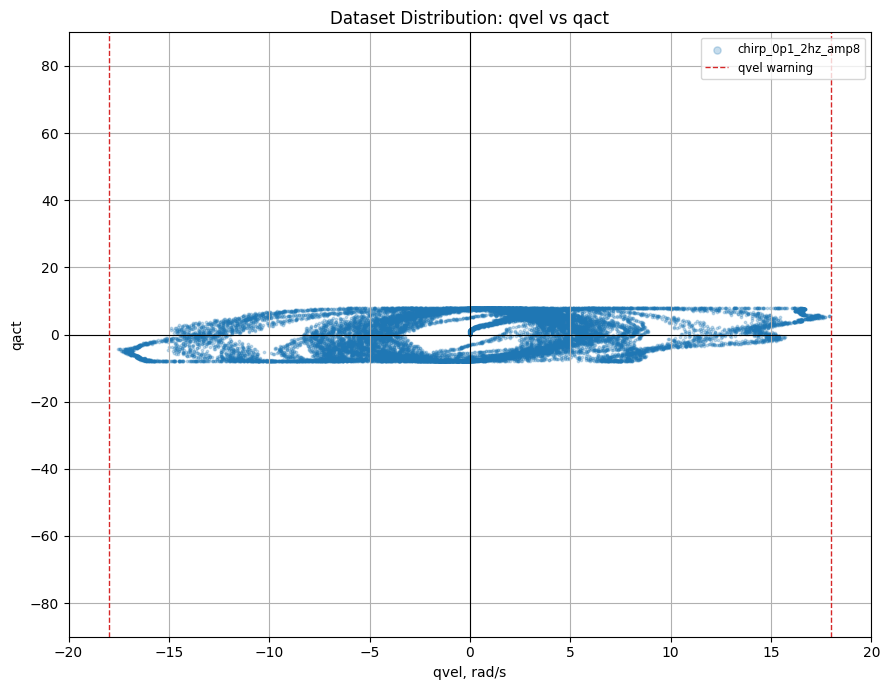

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

for run_name, run_df in dataset_df.groupby("run", sort=True):
    ax.scatter(
        run_df["qvel"],
        run_df["qact"],
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA,
        label=run_name,
    )

ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.axvline(QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0, label="qvel warning")
ax.axvline(-QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0)
ax.set_xlim(QVEL_RANGE)
ax.set_ylim(QACT_RANGE)
ax.set_xlabel("qvel, rad/s")
ax.set_ylabel("qact")
ax.set_title("Dataset Distribution: qvel vs qact")
ax.grid(True)
ax.legend(markerscale=3, fontsize="small", loc="best")
plt.tight_layout()
plt.show()

## Occupancy Heatmap

Occupied bins: 438 / 6400 (6.8%)
qvel range: [-17.553, 17.954] rad/s
qact range: [-8.000, 8.000]
Near qvel warning limit: 0 samples (0.00%)
Outside configured plot ranges: 0 samples (0.00%)


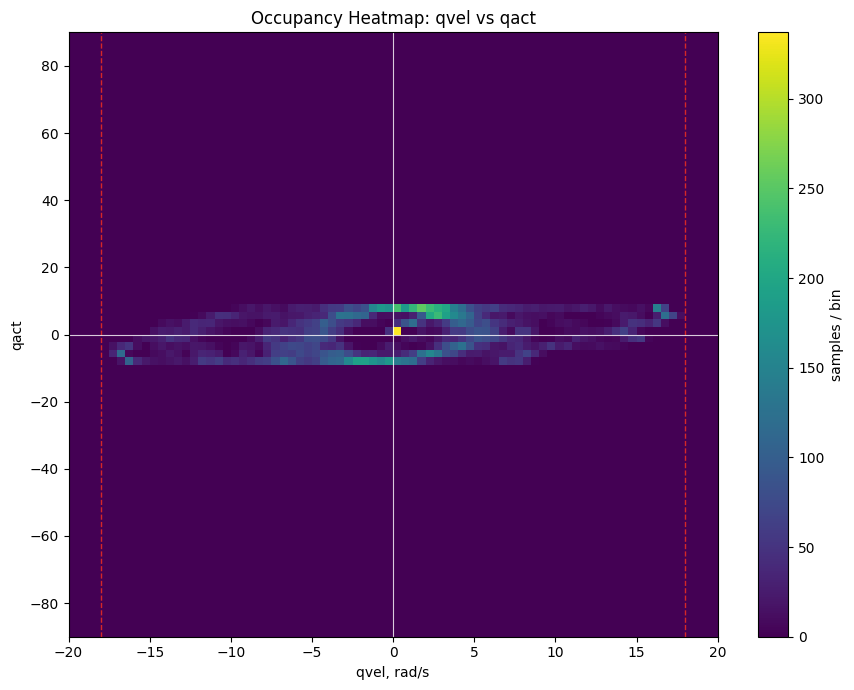

In [6]:
hist, qvel_edges, qact_edges = np.histogram2d(
    dataset_df["qvel"].to_numpy(),
    dataset_df["qact"].to_numpy(),
    bins=[QVEL_BINS, QACT_BINS],
    range=[QVEL_RANGE, QACT_RANGE],
)
occupied = hist > 0
near_qvel_limit = dataset_df["qvel"].abs() >= QVEL_WARNING_LIMIT
outside_view = (
    (dataset_df["qvel"] < QVEL_RANGE[0])
    | (dataset_df["qvel"] > QVEL_RANGE[1])
    | (dataset_df["qact"] < QACT_RANGE[0])
    | (dataset_df["qact"] > QACT_RANGE[1])
)

print(f"Occupied bins: {occupied.sum()} / {occupied.size} ({100.0 * occupied.mean():.1f}%)")
print(f"qvel range: [{dataset_df['qvel'].min():.3f}, {dataset_df['qvel'].max():.3f}] rad/s")
print(f"qact range: [{dataset_df['qact'].min():.3f}, {dataset_df['qact'].max():.3f}]")
print(f"Near qvel warning limit: {near_qvel_limit.sum()} samples ({100.0 * near_qvel_limit.mean():.2f}%)")
print(f"Outside configured plot ranges: {outside_view.sum()} samples ({100.0 * outside_view.mean():.2f}%)")

fig, ax = plt.subplots(figsize=(9, 7))
mesh = ax.pcolormesh(qvel_edges, qact_edges, hist.T, shading="auto")
fig.colorbar(mesh, ax=ax, label="samples / bin")
ax.axvline(QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0)
ax.axvline(-QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0)
ax.axhline(0.0, color="white", linewidth=0.8, alpha=0.8)
ax.axvline(0.0, color="white", linewidth=0.8, alpha=0.8)
ax.set_xlim(QVEL_RANGE)
ax.set_ylim(QACT_RANGE)
ax.set_xlabel("qvel, rad/s")
ax.set_ylabel("qact")
ax.set_title("Occupancy Heatmap: qvel vs qact")
plt.tight_layout()
plt.show()

## Per-Run Heatmaps

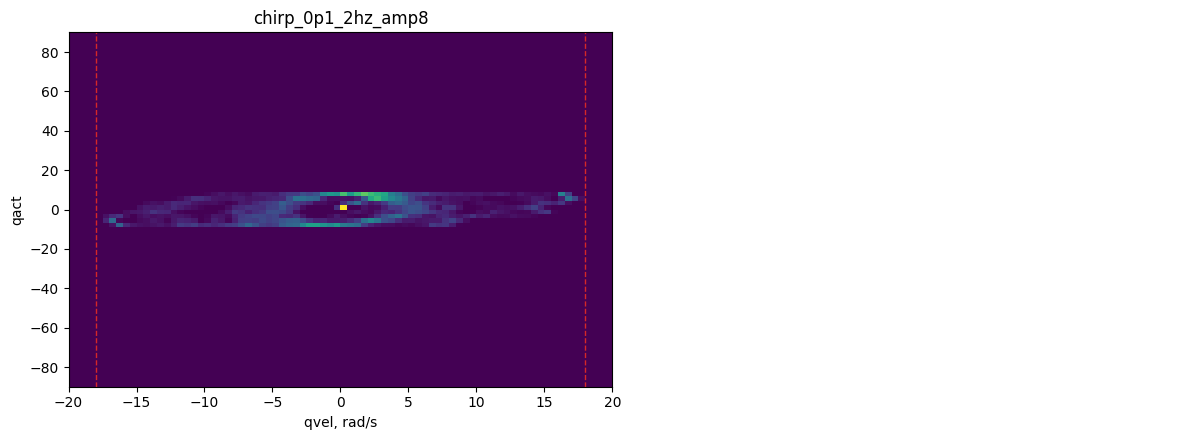

In [7]:
run_names = sorted(dataset_df["run"].unique())
cols = 2
rows = int(np.ceil(len(run_names) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4.5 * rows), squeeze=False)

for axis, run_name in zip(axes.ravel(), run_names):
    run_df = dataset_df[dataset_df["run"] == run_name]
    run_hist, run_qvel_edges, run_qact_edges = np.histogram2d(
        run_df["qvel"].to_numpy(),
        run_df["qact"].to_numpy(),
        bins=[QVEL_BINS, QACT_BINS],
        range=[QVEL_RANGE, QACT_RANGE],
    )
    axis.pcolormesh(run_qvel_edges, run_qact_edges, run_hist.T, shading="auto")
    axis.axvline(QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0)
    axis.axvline(-QVEL_WARNING_LIMIT, color="tab:red", linestyle="--", linewidth=1.0)
    axis.set_title(run_name)
    axis.set_xlabel("qvel, rad/s")
    axis.set_ylabel("qact")
    axis.set_xlim(QVEL_RANGE)
    axis.set_ylim(QACT_RANGE)

for axis in axes.ravel()[len(run_names):]:
    axis.axis("off")

plt.tight_layout()
plt.show()